In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df_bank = pd.read_csv("cleaned_csv/bank_additional_cleaned.csv")
df_customer_details = pd.read_csv("cleaned_csv/customer_details_cleaned.csv")
display(df_bank.sample(2))
display(df_customer_details.sample(2))
df_bank['y_numeric'] = df_bank['y'].map({'yes': 1, 'no': 0})
df_bank.info()

,customer_id,age,job,marital,education,default,housing,loan,contact,duration,...,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y,date,latitude,longitude
36073,1332fa03-82c0-49e5-9233-2d5ed2818131,29,admin.,DIVORCED,university.degree,0.0,1.0,0.0,cellular,238,...,NONEXISTENT,-2.9,92.963,-40.8,-0.15,5076,yes,2018-11-09,27.043,-96.908
34368,66dca445-c653-4a89-9853-5e925fd4bdb8,29,blue-collar,MARRIED,basic,0.0,0.0,0.0,telephone,47,...,NONEXISTENT,-1.8,92.893,-46.2,-0.17,5099,no,2017-09-05,47.821,-68.245


,customer_id,Income,Kidhome,Teenhome,Dt_Customer,NumWebVisitsMonth,ID,year,month
20270,155,74671,1,2,2013-04-17,2,29381fb6-55a4-4135-91e5-657b6783829c,2013,4
30840,1760,118503,2,1,2014-09-08,4,4ae9ef70-54db-43e0-af86-888a2cf8f5cd,2014,9


<class 'pandas.DataFrame'>
RangeIndex: 42667 entries, 0 to 42666
Data columns (total 24 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   customer_id     42667 non-null  str    
 1   age             42667 non-null  int64  
 2   job             42667 non-null  str    
 3   marital         42667 non-null  str    
 4   education       42667 non-null  str    
 5   default         42667 non-null  float64
 6   housing         42667 non-null  float64
 7   loan            42667 non-null  float64
 8   contact         42667 non-null  str    
 9   duration        42667 non-null  int64  
 10  campaign        42667 non-null  int64  
 11  pdays           42667 non-null  int64  
 12  previous        42667 non-null  int64  
 13  poutcome        42667 non-null  str    
 14  emp.var.rate    42667 non-null  float64
 15  cons.price.idx  42667 non-null  float64
 16  cons.conf.idx   42667 non-null  float64
 17  euribor3m       42667 non-null  float64
 1

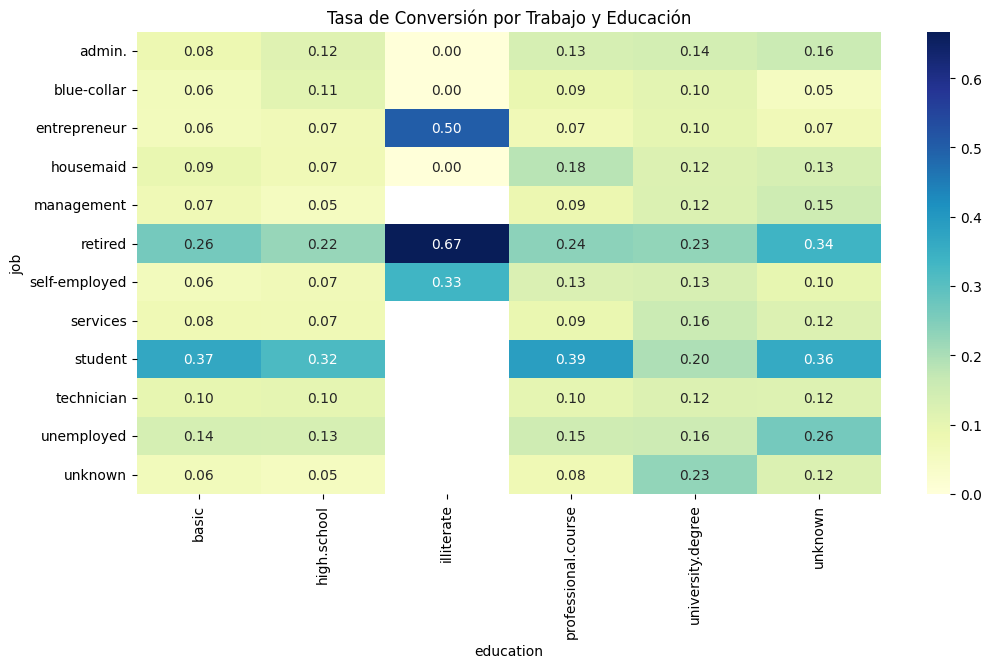

In [30]:
# Agrupamos y normalizamos para ver porcentajes
df_profile = df_bank.groupby(['job', 'education'])['y_numeric'].mean().unstack()

plt.figure(figsize=(12, 6))
sns.heatmap(df_profile, annot=True, cmap="YlGnBu", fmt=".2f")
plt.title('Tasa de Conversión por Trabajo y Educación')
plt.show()

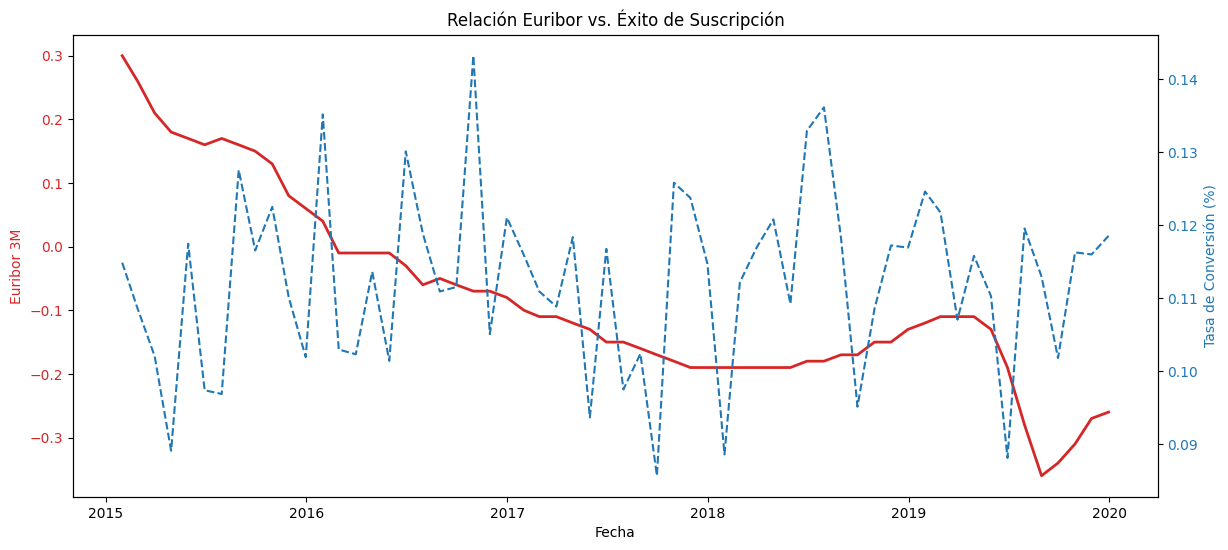

In [ ]:
df_bank['date'] = pd.to_datetime(df_bank['date'])

# Agrupamos por mes
df_monthly = df_bank.resample('ME', on='date').agg({'y_numeric': 'mean', 'euribor3m': 'mean'})

fig, ax1 = plt.subplots(figsize=(14, 6))

# Eje 1: Euribor
ax1.set_xlabel('Fecha')
ax1.set_ylabel('Euribor Mensual', color='tab:red')
ax1.plot(df_monthly.index, df_monthly['euribor3m'], color='tab:red', linewidth=2, label='Euribor')
ax1.tick_params(axis='y', labelcolor='tab:red')

# Eje 2: Tasa de Conversión
ax2 = ax1.twinx()
ax2.set_ylabel('Tasa de Conversión (%)', color='tab:blue')
ax2.plot(df_monthly.index, df_monthly['y_numeric'], color='tab:blue', linestyle='--', label='Conv. Rate')
ax2.tick_params(axis='y', labelcolor='tab:blue')

plt.title('Relación Euribor vs. Éxito de Suscripción')
plt.show()

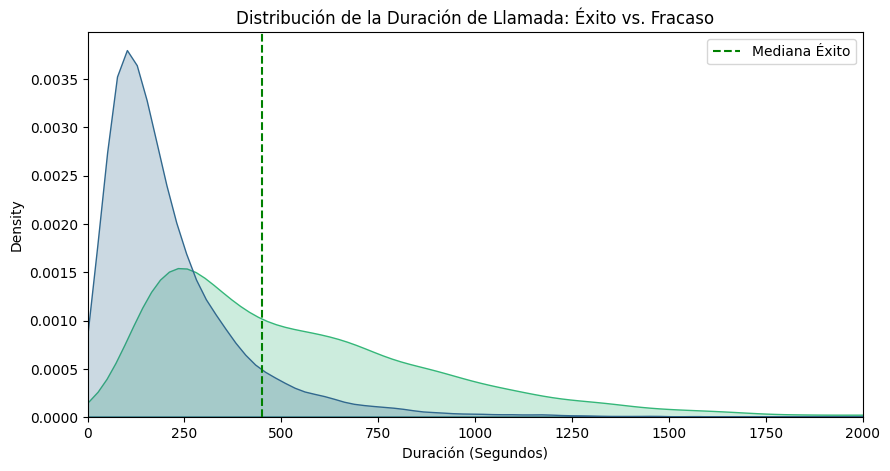

In [ ]:
plt.figure(figsize=(10, 5))
sns.kdeplot(data=df_bank, x="duration", hue="y", fill=True, common_norm=False, palette="viridis")
plt.axvline(df_bank[df_bank['y']=='yes']['duration'].median(), color='green', linestyle='--', label='Mediana Éxito')
plt.xlim(0, 2000) # Limitamos para evitar outliers largos
plt.title('Distribución de la Duración de Llamada: Éxito vs. Fracaso')
plt.xlabel('Duración (Segundos)')
plt.legend()
plt.show()

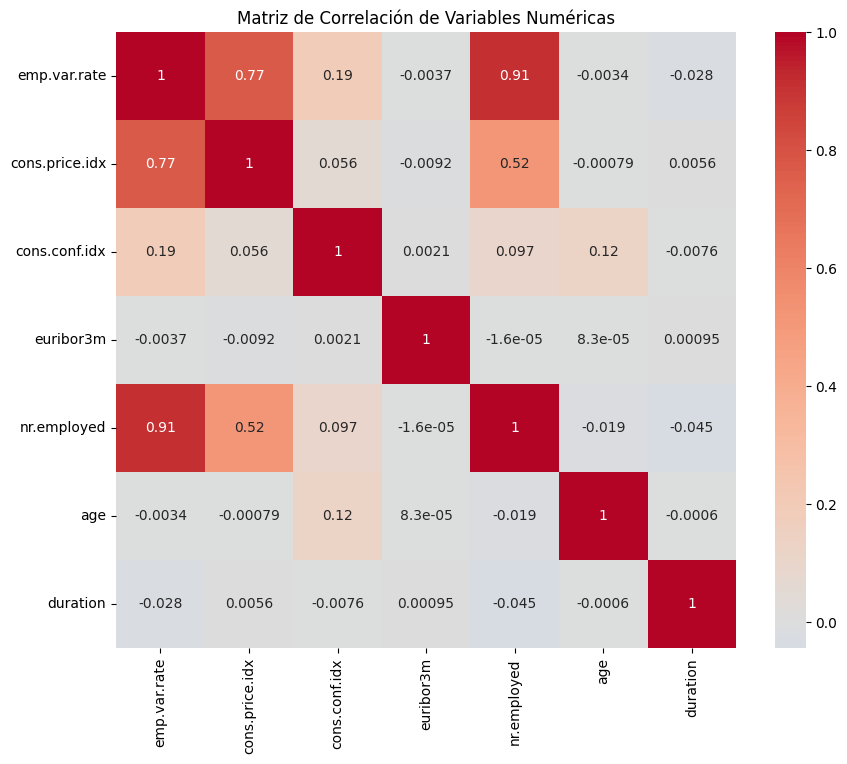

In [ ]:
cols_macro = ['emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed', 'age', 'duration']
corr = df_bank[cols_macro].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0)
plt.title('Matriz de Correlación de Variables Numéricas')
plt.show()

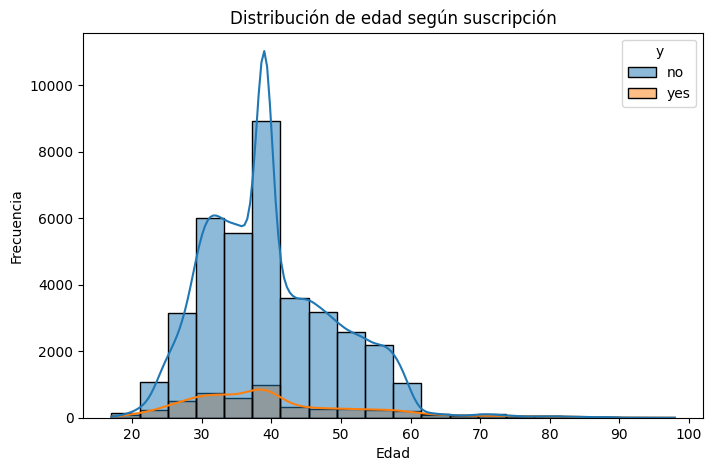

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df_bank,
    x="age",
    hue="y",
    bins=20,
    kde=True
)

plt.title("Distribución de edad según suscripción")
plt.xlabel("Edad")
plt.ylabel("Frecuencia")

plt.show()

In [ ]:
import folium
from folium.plugins import HeatMap
from IPython.display import display

map_center = [df_bank["latitude"].mean(), df_bank["longitude"].mean()]

m = folium.Map(location=map_center, zoom_start=5)

heat_data = df_bank[df_bank["y"]=="yes"][["latitude","longitude"]].values.tolist()

HeatMap(
    heat_data,
    radius=10,  # tamaño de cada punto
    blur=10,    # difuminado
    min_opacity=0.05
).add_to(m)
display(m)